# AI FACE IMAGE Dataset Preprocessing 

In [4]:
import pandas as pd


test_df = pd.read_csv("AI_Face_imagesV2/test_data.csv")
train_df = pd.read_csv("AI_Face_imagesV2/train_data.csv")

### 01. Add Type and Model Columns form Image Path

In [5]:
def extract_type_model(path):
    parts = str(path).strip("/").split("/")
    if len(parts) >= 3:
        return pd.Series([parts[1], parts[2]])
    return pd.Series([None, None])

In [6]:
test_df[["Type", "Model"]] = test_df["Image Path"].apply(extract_type_model)
test_df.head()

,Image Path,Predicted Gender,Predicted Age,Skin Tone,Target,Skin Tone Group,Intersection,Type,Model
0,/AI_Face_imagesV2/DMs/DCFACe/9152/13.jpg,1,2,5,1,1,4,DMs,DCFACe
1,/AI_Face_imagesV2/deepfakes/ff++/crop_img/0_Fa...,0,1,6,1,1,1,deepfakes,ff++
2,/AI_Face_imagesV2/DMs/DCFACe/3912/24.jpg,1,4,8,1,2,5,DMs,DCFACe
3,/AI_Face_imagesV2/GANs/ProGAN images/zip008000...,1,4,5,1,1,4,GANs,ProGAN images
4,/AI_Face_imagesV2/Real/imdb_wiki/imdb/96/nm076...,1,3,7,0,2,5,Real,imdb_wiki


### 02. Duplicate Check

In [7]:
duplicates = test_df[test_df.duplicated(subset=["Image Path"], keep=False)]

duplicates.head()

,Image Path,Predicted Gender,Predicted Age,Skin Tone,Target,Skin Tone Group,Intersection,Type,Model


In [8]:
# test_df.to_csv("test_data_with_types.csv", index=False)

In [9]:
train_df[["Type", "Model"]] = train_df["Image Path"].apply(extract_type_model)

train_df.head()

,Image Path,Predicted Gender,Predicted Age,Skin Tone,Target,Skin Tone Group,Intersection,Type,Model
0,/AI_Face_imagesV2/deepfakes/celebdf/crop_img/0...,1,2,7,1,2,5,deepfakes,celebdf
1,/AI_Face_imagesV2/deepfakes/celebdf/crop_img/0...,1,3,7,1,2,5,deepfakes,celebdf
2,/AI_Face_imagesV2/deepfakes/celebdf/crop_img/0...,1,2,7,1,2,5,deepfakes,celebdf
3,/AI_Face_imagesV2/deepfakes/celebdf/crop_img/0...,1,2,7,1,2,5,deepfakes,celebdf
4,/AI_Face_imagesV2/deepfakes/celebdf/crop_img/0...,1,3,7,1,2,5,deepfakes,celebdf


In [10]:
duplicates = train_df[train_df.duplicated(subset=["Image Path"], keep=False)]
duplicates.head()

,Image Path,Predicted Gender,Predicted Age,Skin Tone,Target,Skin Tone Group,Intersection,Type,Model


In [11]:
train_df.to_csv("train_data_with_types.csv", index=False)

In [12]:
common = train_df[train_df["Image Path"].isin(test_df["Image Path"])]

print(common.head())

Empty DataFrame
Columns: [Image Path, Predicted Gender, Predicted Age, Skin Tone, Target, Skin Tone Group, Intersection, Type, Model]
Index: []


In [13]:
train_df = train_df[train_df["Type"] != "deepfakes"]
test_df = test_df[test_df["Type"] != "deepfakes"]

In [14]:
train_df.head()

,Image Path,Predicted Gender,Predicted Age,Skin Tone,Target,Skin Tone Group,Intersection,Type,Model
268249,/AI_Face_imagesV2/DMs/CommercialTools/dalle2/1...,1,1,7,1,2,5,DMs,CommercialTools
268250,/AI_Face_imagesV2/DMs/CommercialTools/dalle2/1...,0,2,10,1,2,2,DMs,CommercialTools
268251,/AI_Face_imagesV2/DMs/CommercialTools/dalle2/1...,0,2,3,1,0,0,DMs,CommercialTools
268252,/AI_Face_imagesV2/DMs/CommercialTools/dalle2/1...,0,1,3,1,0,0,DMs,CommercialTools
268253,/AI_Face_imagesV2/DMs/CommercialTools/dalle2/1...,0,2,5,1,1,1,DMs,CommercialTools


In [15]:
test_df.head()

,Image Path,Predicted Gender,Predicted Age,Skin Tone,Target,Skin Tone Group,Intersection,Type,Model
0,/AI_Face_imagesV2/DMs/DCFACe/9152/13.jpg,1,2,5,1,1,4,DMs,DCFACe
2,/AI_Face_imagesV2/DMs/DCFACe/3912/24.jpg,1,4,8,1,2,5,DMs,DCFACe
3,/AI_Face_imagesV2/GANs/ProGAN images/zip008000...,1,4,5,1,1,4,GANs,ProGAN images
4,/AI_Face_imagesV2/Real/imdb_wiki/imdb/96/nm076...,1,3,7,0,2,5,Real,imdb_wiki
5,/AI_Face_imagesV2/DMs/StableDiffusion1.5/61/21...,0,2,5,1,1,1,DMs,StableDiffusion1.5


### 03. Check File Existence

In [16]:
import os
from pathlib import Path

def check_file_exists(image_path):
    if pd.isna(image_path):
        return False

    image_path = str(image_path).strip()
    rel_path = image_path.lstrip("/")

    full_path = BASE_DIR / rel_path

    return full_path.exists()


BASE_DIR = Path.cwd()
print(f"Base directory: {BASE_DIR}")

Base directory: c:\Users\Young\School\CSC482\Project


In [17]:
train_df["exists_in_folder"] = train_df["Image Path"].apply(check_file_exists)

print(train_df[["Image Path", "exists_in_folder"]].head())
print(train_df["exists_in_folder"].value_counts(dropna=False))

                                               Image Path  exists_in_folder
268249  /AI_Face_imagesV2/DMs/CommercialTools/dalle2/1...              True
268250  /AI_Face_imagesV2/DMs/CommercialTools/dalle2/1...              True
268251  /AI_Face_imagesV2/DMs/CommercialTools/dalle2/1...              True
268252  /AI_Face_imagesV2/DMs/CommercialTools/dalle2/1...              True
268253  /AI_Face_imagesV2/DMs/CommercialTools/dalle2/1...              True
exists_in_folder
True     707264
False     73062
Name: count, dtype: int64


In [18]:
pd.crosstab(train_df["Model"], train_df["exists_in_folder"], normalize="index")

exists_in_folder,False,True
Model,,
AttGAN,0.000000,1.000000
CommercialTools,0.000000,1.000000
DCFACe,0.078049,0.921951
FFHQ,0.000000,1.000000
MMD_GAN,0.003120,0.996880
MSG_STYLE_GAN,0.000000,1.000000
Palette,0.000000,1.000000
ProGAN images,0.000000,1.000000
STARGAN,0.000000,1.000000


In [19]:
import os
import shutil
from pathlib import Path

def reorganize_images(base_dir):
    for file in base_dir.iterdir():
        if not file.is_file():
            continue

        name = file.name

        if "_" not in name:
            continue

        prefix, rest = name.split("_", 1)

        target_folder = base_dir / prefix
        target_folder.mkdir(exist_ok=True)

        new_path = target_folder / rest

        shutil.move(str(file), str(new_path))


# imdb_wiki = Path("AI_Face_imagesV2/Real/imdb_wiki/imdb")
# reorganize_images(imdb_wiki)

In [20]:
train_df["exists_in_folder"] = train_df["Image Path"].apply(check_file_exists)
pd.crosstab(train_df["Model"], train_df["exists_in_folder"], normalize="index")

exists_in_folder,False,True
Model,,
AttGAN,0.000000,1.000000
CommercialTools,0.000000,1.000000
DCFACe,0.078049,0.921951
FFHQ,0.000000,1.000000
MMD_GAN,0.003120,0.996880
MSG_STYLE_GAN,0.000000,1.000000
Palette,0.000000,1.000000
ProGAN images,0.000000,1.000000
STARGAN,0.000000,1.000000


In [21]:
test_df["exists_in_folder"] = test_df["Image Path"].apply(check_file_exists)

print(test_df[["Image Path", "exists_in_folder"]].head())
print(test_df["exists_in_folder"].value_counts(dropna=False))

                                          Image Path  exists_in_folder
0           /AI_Face_imagesV2/DMs/DCFACe/9152/13.jpg              True
2           /AI_Face_imagesV2/DMs/DCFACe/3912/24.jpg              True
3  /AI_Face_imagesV2/GANs/ProGAN images/zip008000...              True
4  /AI_Face_imagesV2/Real/imdb_wiki/imdb/96/nm076...              True
5  /AI_Face_imagesV2/DMs/StableDiffusion1.5/61/21...              True
exists_in_folder
True     221924
False     22889
Name: count, dtype: int64


In [22]:
pd.crosstab(test_df["Model"], test_df["exists_in_folder"], normalize="index")

exists_in_folder,False,True
Model,,
AttGAN,0.000000,1.000000
CommercialTools,0.000000,1.000000
DCFACe,0.077325,0.922675
FFHQ,0.000000,1.000000
MMD_GAN,0.000000,1.000000
MSG_STYLE_GAN,0.000000,1.000000
Palette,0.000000,1.000000
ProGAN images,0.000000,1.000000
STARGAN,0.000000,1.000000


In [23]:
train_df = train_df[train_df["exists_in_folder"]].drop(columns=["exists_in_folder"])
test_df = test_df[test_df["exists_in_folder"]].drop(columns=["exists_in_folder"])

In [24]:
train_df.to_csv("train_data_cleaned.csv", index=False)
test_df.to_csv("test_data_cleaned.csv", index=False)

### 04. Statistics and Final Cleanup

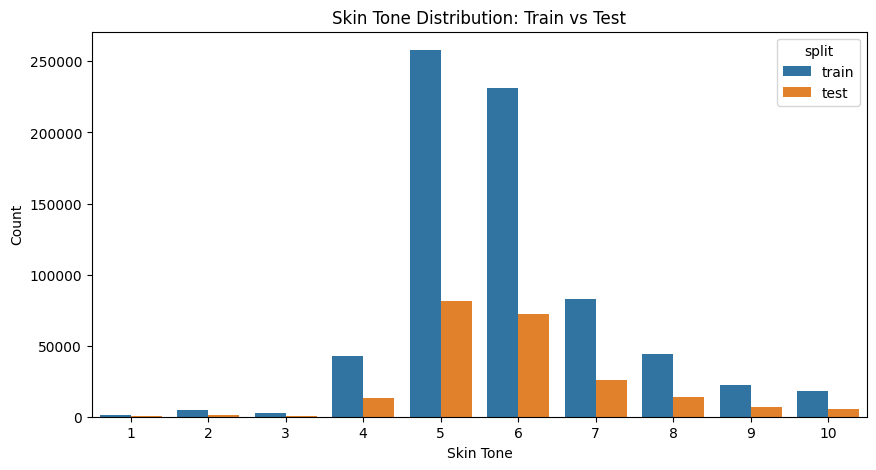

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

train_df["split"] = "train"
test_df["split"] = "test"

df_all = pd.concat([train_df, test_df])
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_all,
    x="Skin Tone",
    hue="split",
    order=sorted(df_all["Skin Tone"].unique())
)

plt.title("Skin Tone Distribution: Train vs Test")
plt.xlabel("Skin Tone")
plt.ylabel("Count")

plt.show()

Text(0.5, 1.05, 'Skin Tone vs Real/Synthetic (Train vs Test)')

<Figure size 1200x500 with 0 Axes>

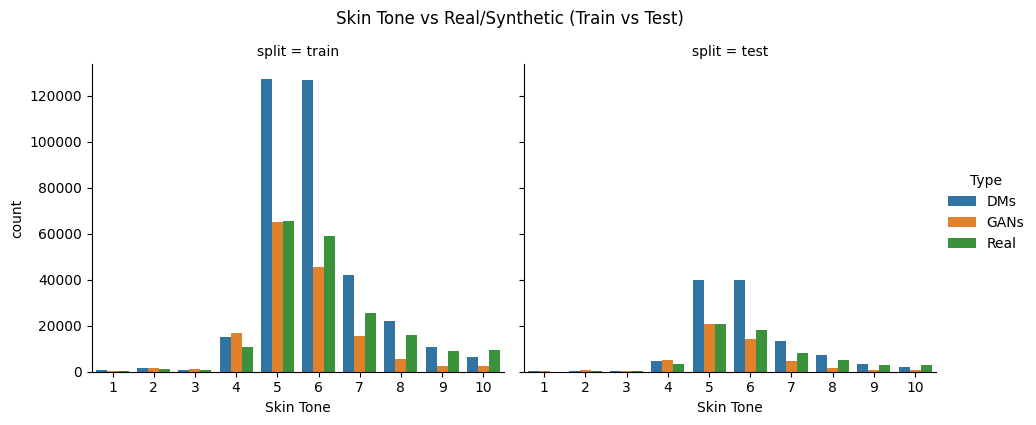

In [35]:
train_df["split"] = "train"
test_df["split"] = "test"

df_all = pd.concat([train_df, test_df])

plt.figure(figsize=(12,5))

g = sns.catplot(
    data=df_all,
    x="Skin Tone",
    hue="Type",
    col="split",
    kind="count",
    height=4,
    aspect=1.2
)

g.fig.suptitle("Skin Tone vs Real/Synthetic (Train vs Test)", y=1.05)

### 05. Add image dimensions

In [43]:
BASE_DIR = Path.cwd()
print(f"Base directory: {BASE_DIR}")

Base directory: c:\Users\Young\School\CSC482\Project


In [57]:
MODEL_RESOLUTION = {
    "FFHQ": (1024, 1024),
    "imdb_wiki": (244, 244),

    "AttGAN": (256, 256),
    "STARGAN": (256, 256),
    "latent_diffusion": (256, 256),

    "CommercialTools": (244, 244),
    "StableDiffusion1.5": (244, 244),
    "StableDiffusion_Inpainting": (244, 244),
    "stylegan3": (244, 244),

    "Palette": (200, 200),
    "taming_transformer_VQGAN": (200, 200),

    "MMD_GAN": (160, 160),
    "MSG_STYLE_GAN": (160, 160),
    "STGAN": (160, 160),

    "ProGAN images": (1024, 1024),
    "StyleGAN2": (1024, 1024),

    "DCFACe": (112, 112),
    "STYLEGAN": (1024, 1024),
}

In [58]:
train_df["Resolution"] = train_df["Model"].map(MODEL_RESOLUTION)
test_df["Resolution"] = test_df["Model"].map(MODEL_RESOLUTION)

test_df.head()
train_df.head()

,Image Path,Predicted Gender,Predicted Age,Skin Tone,Target,Skin Tone Group,Intersection,Type,Model,split,Resolution
268249,/AI_Face_imagesV2/DMs/CommercialTools/dalle2/1...,1,1,7,1,2,5,DMs,CommercialTools,train,"(244, 244)"
268250,/AI_Face_imagesV2/DMs/CommercialTools/dalle2/1...,0,2,10,1,2,2,DMs,CommercialTools,train,"(244, 244)"
268251,/AI_Face_imagesV2/DMs/CommercialTools/dalle2/1...,0,2,3,1,0,0,DMs,CommercialTools,train,"(244, 244)"
268252,/AI_Face_imagesV2/DMs/CommercialTools/dalle2/1...,0,1,3,1,0,0,DMs,CommercialTools,train,"(244, 244)"
268253,/AI_Face_imagesV2/DMs/CommercialTools/dalle2/1...,0,2,5,1,1,1,DMs,CommercialTools,train,"(244, 244)"


In [60]:
train_df["Resolution"].isna().sum()

np.int64(0)

In [61]:
test_df["Resolution"].isna().sum()

np.int64(0)

In [62]:
sorted_columns = [
    "Target",
    "Type",
    "Model",
    "Image Path",
    "Predicted Gender",
    "Predicted Age",
    "Skin Tone",
    "Skin Tone Group",
    "Intersection",
    "Resolution",
]

In [ ]:
train_df = train_df.reindex(columns=sorted_columns)
test_df = test_df.reindex(columns=sorted_columns)

print(train_df.columns.tolist())
print(test_df.columns.tolist())

['Target', 'Type', 'Model', 'Image Path', 'Predicted Gender', 'Predicted Age', 'Skin Tone', 'Skin Tone Group', 'Intersection', 'Resolution']
['Target', 'Type', 'Model', 'Image Path', 'Predicted Gender', 'Predicted Age', 'Skin Tone', 'Skin Tone Group', 'Intersection', 'Resolution']


In [64]:
train_df.to_csv("train_data_final.csv", index=False)
test_df.to_csv("test_data_final.csv", index=False)

## 06. Sampling and Saving Final Datasets

In [74]:
counts = train_df.groupby(["Type", "Skin Tone"]).size()
n = counts.min()

balanced_df = (
    train_df.groupby(["Type", "Skin Tone"], group_keys=False)
    .apply(lambda x: x.sample(n=n, random_state=42))
    .reset_index(drop=True)
)

print(balanced_df.groupby(["Type", "Skin Tone"]).size())

Type  Skin Tone
DMs   1            292
      2            292
      3            292
      4            292
      5            292
      6            292
      7            292
      8            292
      9            292
      10           292
GANs  1            292
      2            292
      3            292
      4            292
      5            292
      6            292
      7            292
      8            292
      9            292
      10           292
Real  1            292
      2            292
      3            292
      4            292
      5            292
      6            292
      7            292
      8            292
      9            292
      10           292
dtype: int64


C:\Users\Young\AppData\Local\Temp\ipykernel_9600\1152138011.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=n, random_state=42))


In [75]:
balanced_df

,Target,Type,Model,Image Path,Predicted Gender,Predicted Age,Skin Tone,Skin Tone Group,Intersection,Resolution,strata
0,1,DMs,StableDiffusion_Inpainting,/AI_Face_imagesV2/DMs/StableDiffusion_Inpainti...,1,2,1,0,3,"(244, 244)",1_2_1
1,1,DMs,DCFACe,/AI_Face_imagesV2/DMs/DCFACe/212/53.jpg,0,2,1,0,0,"(112, 112)",0_2_1
2,1,DMs,DCFACe,/AI_Face_imagesV2/DMs/DCFACe/3381/53.jpg,0,1,1,0,0,"(112, 112)",0_1_1
3,1,DMs,DCFACe,/AI_Face_imagesV2/DMs/DCFACe/9449/50.jpg,0,1,1,0,0,"(112, 112)",0_1_1
4,1,DMs,StableDiffusion1.5,/AI_Face_imagesV2/DMs/StableDiffusion1.5/50/33...,1,2,1,0,3,"(244, 244)",1_2_1
...,...,...,...,...,...,...,...,...,...,...,...
8755,0,Real,imdb_wiki,/AI_Face_imagesV2/Real/imdb_wiki/imdb/77/nm056...,1,3,10,2,5,"(244, 244)",1_3_10
8756,0,Real,imdb_wiki,/AI_Face_imagesV2/Real/imdb_wiki/imdb/83/nm135...,0,1,10,2,2,"(244, 244)",0_1_10
8757,0,Real,imdb_wiki,/AI_Face_imagesV2/Real/imdb_wiki/wiki/13/34389...,1,1,10,2,5,"(244, 244)",1_1_10
8758,0,Real,imdb_wiki,/AI_Face_imagesV2/Real/imdb_wiki/imdb/69/nm025...,0,2,10,2,2,"(244, 244)",0_2_10


Text(0.5, 1.05, 'Skin Tone vs Real/Synthetic (Train vs Test)')

<Figure size 1200x500 with 0 Axes>

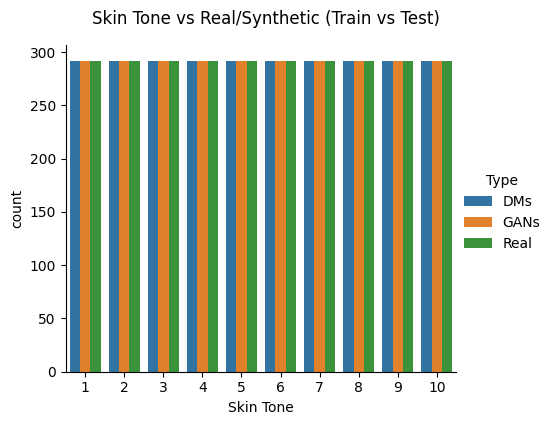

In [76]:
plt.figure(figsize=(12,5))

g = sns.catplot(
    data=balanced_df,
    x="Skin Tone",
    hue="Type",
    kind="count",
    height=4,
    aspect=1.2
)

g.fig.suptitle("Skin Tone vs Real/Synthetic (Train vs Test)", y=1.05)

In [77]:
balanced_df.to_csv("sample.csv", index=False)

In [2]:
import pandas as pd

sample_df = pd.read_csv('sample.csv')

sample_filtered = sample_df.groupby('Model', group_keys=False).apply(
    lambda x: x.sample(1, random_state=42)
).reset_index(drop=True)

print(f'Original: {len(sample_df)} rows')
print(f'Filtered: {len(sample_filtered)} rows\n')

print(sample_filtered[['Model', 'Skin Tone', 'Type', 'Predicted Gender']].head(10))
sample_filtered.to_csv('sample_one_per_model.csv', index=False)

Original: 8760 rows
Filtered: 18 rows

             Model  Skin Tone  Type  Predicted Gender
0           AttGAN          2  GANs                 0
1  CommercialTools          4   DMs                 1
2           DCFACe         10   DMs                 1
3             FFHQ          7  Real                 1
4          MMD_GAN          7  GANs                 1
5    MSG_STYLE_GAN          3  GANs                 0
6          Palette          5   DMs                 0
7    ProGAN images         10  GANs                 0
8          STARGAN          6  GANs                 1
9            STGAN         10  GANs                 1


C:\Users\Young\AppData\Local\Temp\ipykernel_37600\1805235550.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_filtered = sample_df.groupby('Model', group_keys=False).apply(


### 07: Add Local Path to CSV

In [8]:
import pandas as pd

df = pd.read_csv("sample.csv")

print(df.columns.tolist())
df.head()

['Target', 'Type', 'Model', 'Image Path', 'Predicted Gender', 'Predicted Age', 'Skin Tone', 'Skin Tone Group', 'Intersection', 'Resolution', 'strata']


,Target,Type,Model,Image Path,Predicted Gender,Predicted Age,Skin Tone,Skin Tone Group,Intersection,Resolution,strata
0,1,DMs,StableDiffusion_Inpainting,/AI_Face_imagesV2/DMs/StableDiffusion_Inpainti...,1,2,1,0,3,"(244, 244)",1_2_1
1,1,DMs,DCFACe,/AI_Face_imagesV2/DMs/DCFACe/212/53.jpg,0,2,1,0,0,"(112, 112)",0_2_1
2,1,DMs,DCFACe,/AI_Face_imagesV2/DMs/DCFACe/3381/53.jpg,0,1,1,0,0,"(112, 112)",0_1_1
3,1,DMs,DCFACe,/AI_Face_imagesV2/DMs/DCFACe/9449/50.jpg,0,1,1,0,0,"(112, 112)",0_1_1
4,1,DMs,StableDiffusion1.5,/AI_Face_imagesV2/DMs/StableDiffusion1.5/50/33...,1,2,1,0,3,"(244, 244)",1_2_1


In [9]:
from pathlib import Path

dataset_root = Path(r"C:\Users\Young\School\CSC482\Project")

df["image_path"] = (
    df["Image Path"]
    .astype(str)
    .str.strip()
    .str.replace("\\", "/", regex=False)
    .str.lstrip("/")
    .apply(lambda p: str((dataset_root / p).resolve()))
)

df

,Target,Type,Model,Image Path,Predicted Gender,Predicted Age,Skin Tone,Skin Tone Group,Intersection,Resolution,strata,image_path
0,1,DMs,StableDiffusion_Inpainting,/AI_Face_imagesV2/DMs/StableDiffusion_Inpainti...,1,2,1,0,3,"(244, 244)",1_2_1,C:\Users\Young\School\CSC482\Project\AI_Face_i...
1,1,DMs,DCFACe,/AI_Face_imagesV2/DMs/DCFACe/212/53.jpg,0,2,1,0,0,"(112, 112)",0_2_1,C:\Users\Young\School\CSC482\Project\AI_Face_i...
2,1,DMs,DCFACe,/AI_Face_imagesV2/DMs/DCFACe/3381/53.jpg,0,1,1,0,0,"(112, 112)",0_1_1,C:\Users\Young\School\CSC482\Project\AI_Face_i...
3,1,DMs,DCFACe,/AI_Face_imagesV2/DMs/DCFACe/9449/50.jpg,0,1,1,0,0,"(112, 112)",0_1_1,C:\Users\Young\School\CSC482\Project\AI_Face_i...
4,1,DMs,StableDiffusion1.5,/AI_Face_imagesV2/DMs/StableDiffusion1.5/50/33...,1,2,1,0,3,"(244, 244)",1_2_1,C:\Users\Young\School\CSC482\Project\AI_Face_i...
...,...,...,...,...,...,...,...,...,...,...,...,...
8755,0,Real,imdb_wiki,/AI_Face_imagesV2/Real/imdb_wiki/imdb/77/nm056...,1,3,10,2,5,"(244, 244)",1_3_10,C:\Users\Young\School\CSC482\Project\AI_Face_i...
8756,0,Real,imdb_wiki,/AI_Face_imagesV2/Real/imdb_wiki/imdb/83/nm135...,0,1,10,2,2,"(244, 244)",0_1_10,C:\Users\Young\School\CSC482\Project\AI_Face_i...
8757,0,Real,imdb_wiki,/AI_Face_imagesV2/Real/imdb_wiki/wiki/13/34389...,1,1,10,2,5,"(244, 244)",1_1_10,C:\Users\Young\School\CSC482\Project\AI_Face_i...
8758,0,Real,imdb_wiki,/AI_Face_imagesV2/Real/imdb_wiki/imdb/69/nm025...,0,2,10,2,2,"(244, 244)",0_2_10,C:\Users\Young\School\CSC482\Project\AI_Face_i...


In [10]:
df.to_csv("sample_prepared.csv", index=False)

### Combined Data For Build Data

In [2]:
import pandas as pd

test = pd.read_csv("outputs/test_data_final.csv")
train = pd.read_csv("outputs/train_data_final.csv")

test["dataset"] = "test"
train["dataset"] = "train"

merged_df = pd.concat([test, train], ignore_index=True)

merged_df.to_csv("outputs/full_dataset.csv", index=False)

In [5]:
from pathlib import Path

dataset_root = Path(r"C:\Users\Young\School\CSC482\Project")

merged_df["image_path"] = (
    merged_df["Image Path"]
    .astype(str)
    .str.strip()
    .str.replace("\\", "/", regex=False)
    .str.lstrip("/")
    .apply(lambda p: str((dataset_root / p).resolve()))
)

merged_df

,Target,Type,Model,Image Path,Predicted Gender,Predicted Age,Skin Tone,Skin Tone Group,Intersection,Resolution,dataset,image_path
0,1,DMs,DCFACe,/AI_Face_imagesV2/DMs/DCFACe/9152/13.jpg,1,2,5,1,4,"(112, 112)",test,C:\Users\Young\School\CSC482\Project\AI_Face_i...
1,1,DMs,DCFACe,/AI_Face_imagesV2/DMs/DCFACe/3912/24.jpg,1,4,8,2,5,"(112, 112)",test,C:\Users\Young\School\CSC482\Project\AI_Face_i...
2,1,GANs,ProGAN images,/AI_Face_imagesV2/GANs/ProGAN images/zip008000...,1,4,5,1,4,"(1024, 1024)",test,C:\Users\Young\School\CSC482\Project\AI_Face_i...
3,0,Real,imdb_wiki,/AI_Face_imagesV2/Real/imdb_wiki/imdb/96/nm076...,1,3,7,2,5,"(244, 244)",test,C:\Users\Young\School\CSC482\Project\AI_Face_i...
4,1,DMs,StableDiffusion1.5,/AI_Face_imagesV2/DMs/StableDiffusion1.5/61/21...,0,2,5,1,1,"(244, 244)",test,C:\Users\Young\School\CSC482\Project\AI_Face_i...
...,...,...,...,...,...,...,...,...,...,...,...,...
929183,0,Real,imdb_wiki,/AI_Face_imagesV2/Real/imdb_wiki/wiki/99/95986...,0,4,5,1,1,"(244, 244)",train,C:\Users\Young\School\CSC482\Project\AI_Face_i...
929184,0,Real,imdb_wiki,/AI_Face_imagesV2/Real/imdb_wiki/wiki/99/96117...,1,3,6,1,4,"(244, 244)",train,C:\Users\Young\School\CSC482\Project\AI_Face_i...
929185,0,Real,imdb_wiki,/AI_Face_imagesV2/Real/imdb_wiki/wiki/99/96117...,1,3,6,1,4,"(244, 244)",train,C:\Users\Young\School\CSC482\Project\AI_Face_i...
929186,0,Real,imdb_wiki,/AI_Face_imagesV2/Real/imdb_wiki/wiki/99/96159...,1,3,7,2,5,"(244, 244)",train,C:\Users\Young\School\CSC482\Project\AI_Face_i...


In [6]:
merged_df.to_csv("outputs/full_dataset.csv", index=False)